local machine for ssh

ssh -L 55992:localhost:55992 lmoreau@roomba.hep.anl.gov

In [1]:
import merlin_spectra
from merlin_spectra.emission import EmissionLineInterpolator

import os
import copy

import numpy as np
from numpy import ndarray
import yt
from yt.frontends.ramses.field_handlers import RTFieldFileHandler

import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.constants import c


# Loading the Data

COLLAPSE CELL BELOW FOR SIMPLICITY: Cell below is all of the field handeling and data loading required before we can start. 

In [2]:
# Path to the installed package
merlin_path = os.path.dirname(merlin_spectra.__file__)

# Path to the linelists folder inside MERLIN
line_list = os.path.join(merlin_path, "linelists/linelist.dat")

print("MERLIN path:", merlin_path)
print("Line list path:", line_list)

filename = "/Users/lamoreau/python/ASpec/SimulationFiles/output_00273/info_00273.txt"
# need to make this a relative path that is consistant
# should be able to select files with GUI if we are going to have one

lines=["H1_6562.80A","O1_1304.86A","O1_6300.30A","O2_3728.80A","O2_3726.10A",
       "O3_1660.81A","O3_1666.15A","O3_4363.21A","O3_4958.91A","O3_5006.84A", 
       "He2_1640.41A","C2_1335.66A","C3_1906.68A","C3_1908.73A","C4_1549.00A",
       "Mg2_2795.53A","Mg2_2802.71A","Ne3_3868.76A","Ne3_3967.47A",
       "N5_1238.82A",
       "N5_1242.80A","N4_1486.50A","N3_1749.67A","S2_6716.44A","S2_6730.82A"]

wavelengths=np.array([6562.80, 1304.86, 6300.30, 3728.80, 3726.10, 1660.81, 1666.15,
             4363.21, 4958.91, 5006.84, 1640.41, 1335.66,
             1906.68, 1908.73, 1549.00, 2795.53, 2802.71, 3868.76,
             3967.47, 1238.82, 1242.80, 1486.50, 1749.67, 6716.44, 6730.82])

cell_fields = [
    "Density",
    "x-velocity",
    "y-velocity",
    "z-velocity",
    "Pressure",
    "Metallicity",
    "xHI",
    "xHII",
    "xHeII",
    "xHeIII",
]

epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

# Ionization Parameter Field
# Based on photon densities in bins 2-4
# Don't include bin 1 -> Lyman Werner non-ionizing
def _ion_param(field, data):
    p = RTFieldFileHandler.get_rt_parameters(ds).copy()
    p.update(ds.parameters)

    cgs_c = 2.99792458e10     #light velocity

    # Convert to physical photon number density in cm^-3
    pd_2 = data['ramses-rt','Photon_density_2']*p["unit_pf"]/cgs_c
    pd_3 = data['ramses-rt','Photon_density_3']*p["unit_pf"]/cgs_c
    pd_4 = data['ramses-rt','Photon_density_4']*p["unit_pf"]/cgs_c

    photon = pd_2 + pd_3 + pd_4

    return photon/data['gas', 'number_density']


def _my_temperature(field, data):
    #y(i): abundance per hydrogen atom
    XH_RAMSES=0.76 #defined by RAMSES in cooling_module.f90
    YHE_RAMSES=0.24 #defined by RAMSES in cooling_module.f90
    mH_RAMSES=yt.YTArray(1.6600000e-24,"g") #defined by RAMSES in cooling_module.f90
    kB_RAMSES=yt.YTArray(1.3806200e-16,"erg/K") #defined by RAMSES in cooling_module.f90

    dn=data["ramses","Density"].in_cgs()
    pr=data["ramses","Pressure"].in_cgs()
    yHI=data["ramses","xHI"]
    yHII=data["ramses","xHII"]
    yHe = YHE_RAMSES*0.25/XH_RAMSES
    yHeII=data["ramses","xHeII"]*yHe
    yHeIII=data["ramses","xHeIII"]*yHe
    yH2=1.-yHI-yHII
    yel=yHII+yHeII+2*yHeIII
    mu=(yHI+yHII+2.*yH2 + 4.*yHe) / (yHI+yHII+yH2 + yHe + yel)
    return pr/dn * mu * mH_RAMSES / kB_RAMSES


# TODO see if it works in emission.py
# Luminosity field
# Cloudy Intensity obtained assuming height = 1cm
# Return intensity values erg/s/cm**2
# Multiply intensity at each pixel by volume of pixel -> luminosity
def get_luminosity(line):
   def _luminosity(field, data):
      return data['gas', 'flux_' + line]*data['gas', 'volume']
   return copy.deepcopy(_luminosity)


#number density of hydrogen atoms
def _my_H_nuclei_density(field, data):
    dn=data["ramses","Density"].in_cgs()
    XH_RAMSES=0.76 #defined by RAMSES in cooling_module.f90
    YHE_RAMSES=0.24 #defined by RAMSES in cooling_module.f90
    mH_RAMSES=yt.YTArray(1.6600000e-24,"g") #defined by RAMSES in cooling_module.f90

    return dn*XH_RAMSES/mH_RAMSES


def _pressure(field, data):
    if 'hydro_thermal_pressure' in dir(ds.fields.ramses): # and 
        #'Pressure' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_thermal_pressure']


def _xHI(field, data):
    if 'hydro_xHI' in dir(ds.fields.ramses): # and \
        #'xHI' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHI']


def _xHII(field, data):
    if 'hydro_xHII' in dir(ds.fields.ramses): # and \
        #'xHII' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHII']


def _xHeII(field, data):
    if 'hydro_xHeII' in dir(ds.fields.ramses): # and \
        #'xHeII' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHeII']


def _xHeIII(field, data):
    if 'hydro_xHeIII' in dir(ds.fields.ramses): # and \
        #'xHeIII' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHeIII']

'''
-------------------------------------------------------------------------------
Load Simulation Data
Add Derived Fields
-------------------------------------------------------------------------------
'''

ds = yt.load(filename, extra_particle_fields=epf)

ds.add_field(
    ("gas","number_density"),
    function=_my_H_nuclei_density,
    sampling_type="cell",
    units="1/cm**3",
    force_override=True
)


ds.add_field(
    ("ramses","Pressure"),
    function=_pressure,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHI"),
    function=_xHI,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHII"),
    function=_xHII,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHeII"),
    function=_xHeII,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHeIII"),
    function=_xHeIII,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("gas","my_temperature"),
    function=_my_temperature,
    sampling_type="cell",
    # TODO units
    #units="K",
    #units="K*cm**3/erg",
    units='K*cm*dyn/erg',
    force_override=True
)

# Ionization parameter
ds.add_field(
    ('gas', 'ion_param'),
    function=_ion_param,
    sampling_type="cell",
    units="cm**3",
    force_override=True
)

ds.add_field(
    ("gas","my_H_nuclei_density"),
    function=_my_H_nuclei_density,
    sampling_type="cell",
    units="1/cm**3",
    force_override=True
)

# Normalize by Density Squared Flag
dens_normalized = True
if dens_normalized: 
    units = '1/cm**6'
else:
    units = '1'


print(lines)
print(len(lines))

# Instance of EmissionLineInterpolator for line list at filename
# print(line_list) #see cell 2 above for details
emission_interpolator = EmissionLineInterpolator(lines, line_list) #why is this interpolated? computational speedup?

# Add flux and luminosity fields for all lines in the list
for i, line in enumerate(lines):
    ds.add_field(
        ('gas', 'flux_' + line),
        function=emission_interpolator.get_line_emission(
            i, dens_normalized=dens_normalized
        ),
        sampling_type='cell',
        units=units,
        force_override=True
    )
    # TODO change get_line_emission to accept line not idx

    ds.add_field(
        ('gas', 'luminosity_' + line),
        function=emission_interpolator.get_luminosity(lines[i]),
        #function=get_luminosity(lines[i]),
        sampling_type='cell',
        units='1/cm**3',
        force_override=True
    )

print(dir(ds.fields))


MERLIN path: /Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/merlin_spectra
Line list path: /Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/merlin_spectra/linelists/linelist.dat


yt : [WARNING  ] 2026-05-08 10:20:40,043 `namelist.txt` file found but missing package f90nml to read it:
Traceback (most recent call last):
  File "/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/yt/frontends/ramses/data_structures.py", line 1139, in read_namelist
    nml = f90nml.read(f)
  File "/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/yt/utilities/on_demand_imports.py", line 39, in __call__
    raise self.error
  File "/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/yt/utilities/on_demand_imports.py", line 77, in inner
    return func(self)
  File "/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/yt/utilities/on_demand_imports.py", line 420, in read
    from f90nml import read
ModuleNotFoundError: No module named 'f90nml'
Something went wrong while trying to lazy-import f90nml. Please make sure that f90nml is properly installed.
If the problem persists, please file an issue at https://github.com/yt-project/yt/issues/n

['H1_6562.80A', 'O1_1304.86A', 'O1_6300.30A', 'O2_3728.80A', 'O2_3726.10A', 'O3_1660.81A', 'O3_1666.15A', 'O3_4363.21A', 'O3_4958.91A', 'O3_5006.84A', 'He2_1640.41A', 'C2_1335.66A', 'C3_1906.68A', 'C3_1908.73A', 'C4_1549.00A', 'Mg2_2795.53A', 'Mg2_2802.71A', 'Ne3_3868.76A', 'Ne3_3967.47A', 'N5_1238.82A', 'N5_1242.80A', 'N4_1486.50A', 'N3_1749.67A', 'S2_6716.44A', 'S2_6730.82A']
25
/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/merlin_spectra/linelists/linelist-all.dat
/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/merlin_spectra/linelists/linelist-all.dat
minU=-9.0, maxU=2.0, stepU=0.5, minN=-4.0, maxN=7.0, stepN=0.5, minT=1.0, maxT=8.0, stepT=0.2
Line List Shape = (26, 19044)
23 23 36
['DM', 'cloud', 'cloud_tracer', 'deposit', 'dust', 'dust_tracer', 'gas', 'gas_tracer', 'gravity', 'index', 'io', 'nbody', 'ramses', 'ramses-rt', 'rt', 'sink', 'sink_csv', 'star', 'star_tracer']


### Calculating Luminosity Distance

In [3]:
zsource = ds.current_redshift

# From sedcontinuum file, this is what I will assume 
# is the cosmology used to create the simulation
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)


Cell below
    * Sets up arrays to load in lines
    * Finds COM of all star particles to center the galaxy in selected region

In [4]:
# --------------------------------------------
# INPUT: list of emission lines (exact names)
# --------------------------------------------
lines = np.array([
    'H1 6562.80A', 'O1 1304.86A', 'O1 6300.30A', 'O2 3728.80A',
    'O2 3726.10A', 'O3 1660.81A', 'O3 1666.15A', 'O3 4363.21A',
    'O3 4958.91A', 'O3 5006.84A', 'He2 1640.41A', 'C2 1335.66A',
    'C3 1906.68A', 'C3 1908.73A', 'C4 1549.00A', 'Mg2 2795.53A',
    'Mg2 2802.71A', 'Ne3 3868.76A', 'Ne3 3967.47A', 'N5 1238.82A',
    'N5 1242.80A', 'N4 1486.50A', 'N3 1749.67A', 'S2 6716.44A',
    'S2 6730.82A'
])
# --------------------------------------------
# Convert "O1 1304.86A" → "O1_1304.86A"
# --------------------------------------------
lines = np.array([l.replace(" ", "_") for l in lines])

# -------------------------------------------------------------------------
# PREP: load all gas data and cell volume once (faster than inside loop)
# -------------------------------------------------------------------------
ad = ds.all_data()
# ----------------------------------------------------
# OUTPUT ARRAYS
# ----------------------------------------------------
total_fluxes = []
total_luminosities = []

# creating proj of a boxed region
cx = np.mean(ad["star", "particle_position_x"])
cy = np.mean(ad["star", "particle_position_y"])
cz = np.mean(ad["star", "particle_position_z"])
center = [cx, cy, cz]
halfa = ds.quan(20, "kpc")

low_edge = [center[0] - halfa, center[1] - halfa, center[2] - halfa]
high_edge = [center[0] + halfa, center[1] + halfa, center[2] + halfa]

cube_region = ds.region(center, low_edge, high_edge)

ad_box = cube_region


cell_volume_box = ad_box["cell_volume"]   # in cm^3
# ----------------------------------------------------
# OUTPUT ARRAYS
# ----------------------------------------------------
total_fluxes_box = []
total_luminosities_box = []


cell_vol  = cell_volume_box.to("cm**3").d[None, :]     # broadcast to shape (1, Ncells)

yt : [INFO     ] 2026-05-08 10:20:43,646 Identified   384/  384 intersecting domains (  385 through hilbert key indexing)
yt : [INFO     ] 2026-05-08 10:20:45,542 Identified   384/  384 intersecting domains (  384 through hilbert key indexing)


Loads all luminosity fields and sums to get total luminosity from region in erg / s

In [5]:
lum_fields  = [("gas", f"luminosity_{line}") for line in lines]
lum_data  = np.vstack([ad_box[f] for f in lum_fields])  # shape: (Nlines, Ncells) #.to("erg/s").d
total_luminosities_box  = lum_data.sum(axis=1).to_value()

In [6]:
print(total_luminosities_box)
print(type(total_luminosities_box))

[3.90955858e+41 3.31949205e+36 2.26410702e+34 2.72101305e+36
 1.20475976e+37 2.26032755e+37 8.64213222e+35 2.53087718e+36
 9.26514983e+35 8.30460881e+36 1.03474205e+42 4.13492301e+33
 4.83716059e+35 1.49603706e+37 1.26528935e+37 4.24149818e+29
 2.19186638e+37 1.10545778e+37 5.37404641e+35 1.63110992e+35
 6.97985519e+32 3.48213989e+32 1.58560762e+33 1.32286373e+36
 2.66617959e+36]
<class 'numpy.ndarray'>


In [7]:
# # in micron
# wav_obs0=wav*(redsh0+1)*1e-4
# wav_obs1=wav*(redsh1+1)*1e-4
# # F=L/(4pi*d_L^2) [erg/s/cm2/Amsr]
# # L_lamb/(1+z) L/(1+z)
# y1_obs0=np.array(xf*10**(y1-np.log10(4.*np.pi)-2*np.log10(d_L0))/(1+redsh0))
# y1_obs1=np.array(xf*10**(y1-np.log10(4.*np.pi)-2*np.log10(d_L1))/(1+redsh1))
# # convert to micro Jy: 1e-23 cgs 

# All the math above is in the redshift conversion cell

# # convert to uJy
# mag=10.0
# nu=3e10/(wav*1e-8)
# conv=wav/nu
# y1_obs0=y1_obs0*conv/1e-29*mag*(1+redsh0)**2
# y1_obs1=y1_obs1*conv/1e-29*mag*(1+redsh1)**2

### Redshift Conversions

This cell contains all the redshift related conversions.

Turns luminosity into flux at detector and wavelength from source to observed.

In [8]:
DL = cosmo.luminosity_distance(zsource).to("cm")
Flumd = total_luminosities_box/4/np.pi/(DL)**2/(1+zsource)
lambdaobs = (wavelengths * (1 + zsource) * u.Angstrom).to(u.micron)
print(Flumd)
print(lambdaobs)

Flumd * lambdaobs**2/c.to(u.micron/u.second)

[1.47660017e-20 1.25373809e-25 8.55129993e-28 1.02769872e-25
 4.55025403e-25 8.53702527e-25 3.26404468e-26 9.55886346e-26
 3.49935204e-26 3.13656555e-25 3.90811455e-20 1.56171800e-28
 1.82694593e-26 5.65037850e-25 4.77886809e-25 1.60197035e-32
 8.27845445e-25 4.17520063e-25 2.02972220e-26 6.16053483e-27
 2.63621970e-29 1.31516851e-29 5.98867732e-29 4.99632061e-26
 1.00698868e-25] 1 / cm2
[8.64392101 1.71864246 8.29817997 4.91123494 4.90767874 2.18746731
 2.19450067 5.74682187 6.53142353 6.59455255 2.16059829 1.75920941
 2.51130482 2.5140049  2.04020138 3.6820169  3.69147374 5.09557747
 5.22558927 1.63166061 1.6369027  1.95788209 2.30450559 8.84628159
 8.86522161] micron


<Quantity [3.68013533e-33, 1.23525663e-39, 1.96416123e-40, 8.26849619e-39,
           3.65567175e-38, 1.36260195e-38, 5.24332560e-40, 1.05303069e-38,
           4.97946432e-39, 4.54992598e-38, 6.08547718e-34, 1.61219286e-42,
           3.84329618e-40, 1.19121205e-38, 6.63514495e-39, 7.24444843e-46,
           3.76294722e-38, 3.61612525e-38, 1.84878514e-39, 5.47088229e-41,
           2.35617003e-43, 1.68164285e-43, 1.06087873e-42, 1.30422078e-38,
           2.63987326e-38] micron s / cm2>

This is just a generalized version where I can change the redshift too.

In [9]:
print(ds.current_redshift)

12.171087046255657


In [10]:
ztest = ds.current_redshift
print(total_luminosities_box)
DL = cosmo.luminosity_distance(ztest).to("cm")
print(DL)
Flumd = total_luminosities_box/4/np.pi/(DL)**2
lambdaobs = (np.array(wavelengths) * (1 + ztest) * u.Angstrom).to(u.micron)
print(Flumd)
print(lambdaobs)

[3.90955858e+41 3.31949205e+36 2.26410702e+34 2.72101305e+36
 1.20475976e+37 2.26032755e+37 8.64213222e+35 2.53087718e+36
 9.26514983e+35 8.30460881e+36 1.03474205e+42 4.13492301e+33
 4.83716059e+35 1.49603706e+37 1.26528935e+37 4.24149818e+29
 2.19186638e+37 1.10545778e+37 5.37404641e+35 1.63110992e+35
 6.97985519e+32 3.48213989e+32 1.58560762e+33 1.32286373e+36
 2.66617959e+36]
3.999600957718097e+29 cm
[1.94484293e-19 1.65130936e-24 1.12629916e-26 1.35359092e-24
 5.99317919e-24 1.12441903e-23 4.29910166e-25 1.25900623e-24
 4.60902703e-25 4.13119779e-24 5.14741170e-19 2.05695238e-27
 2.40628639e-25 7.44216271e-24 6.29428875e-24 2.10996909e-31
 1.09036244e-23 5.49919309e-24 2.67336477e-25 8.11409405e-26
 3.47218791e-28 1.73221989e-28 7.88773903e-28 6.58069737e-25
 1.32631355e-24] 1 / cm2
[8.64392101 1.71864246 8.29817997 4.91123494 4.90767874 2.18746731
 2.19450067 5.74682187 6.53142353 6.59455255 2.16059829 1.75920941
 2.51130482 2.5140049  2.04020138 3.6820169  3.69147374 5.09557747


I still need to understand exactly how the two functions below work but now we are approximately right in order of magnitude

[6562.8  1304.86 6300.3  3728.8  3726.1  1660.81 1666.15 4363.21 4958.91
 5006.84 1640.41 1335.66 1906.68 1908.73 1549.   2795.53 2802.71 3868.76
 3967.47 1238.82 1242.8  1486.5  1749.67 6716.44 6730.82]
[1.94484293e-19 1.65130936e-24 1.12629916e-26 1.35359092e-24
 5.99317919e-24 1.12441903e-23 4.29910166e-25 1.25900623e-24
 4.60902703e-25 4.13119779e-24 5.14741170e-19 2.05695238e-27
 2.40628639e-25 7.44216271e-24 6.29428875e-24 2.10996909e-31
 1.09036244e-23 5.49919309e-24 2.67336477e-25 8.11409405e-26
 3.47218791e-28 1.73221989e-28 7.88773903e-28 6.58069737e-25
 1.32631355e-24] 1 / cm2


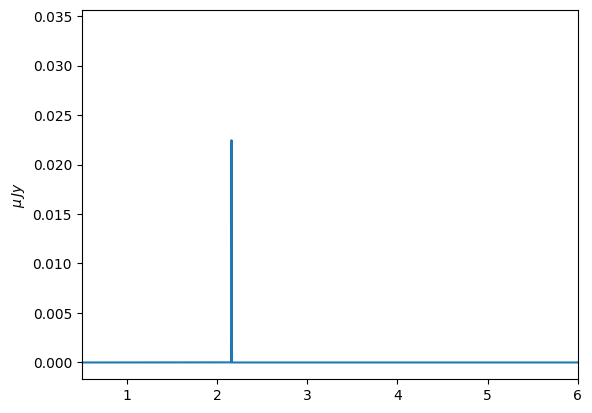

In [11]:
def ergcm2s_to_jyhz(F_erg_cm2_s):
    # 1 erg/s/cm^2 = 1e23 Jy Hz

    return F_erg_cm2_s * 1e23

def gaussian_spectrum_from_integrated_flux_erg(
    lambda_array: ndarray,          # wavelength grid (Å)
    line_cents_array: ndarray,      # line centers (Å)
    sigma_v_kms: ndarray,           # Gaussian sigma in km/s (scalar or array)
    F_line_erg_cm2_s: ndarray       # integrated fluxes (erg/s/cm^2), array
):
    """
    Returns the combined line spectrum S(λ) in Jy.
    Gaussian profile defined in frequency domain but evaluated on λ grid.
    """

    # ---- Convert inputs to arrays ----
    lambda_array = np.asarray(lambda_array, float)        # (Nλ,)
    line_cents_array = np.asarray(line_cents_array, float)  # (Nlines,)
    sigma_v_kms = np.asarray(sigma_v_kms, float)            # scalar or (Nlines,)
    F_line_erg_cm2_s = np.asarray(F_line_erg_cm2_s, float)  # (Nlines,)

    # ---- Convert wavelength to frequency ----
    # Å → cm
    lam_cm = lambda_array * 1e-8
    lam0_cm = line_cents_array * 1e-8

    # λ → ν conversion
    nu_array = c.cgs.to_value() / lam_cm         # Hz, shape (Nλ,)
    nu0 = c.cgs.to_value()  / lam0_cm             # Hz, shape (Nlines,)

    # ---- Convert integrated flux to (Jy Hz) ----
    F_jyhz = ergcm2s_to_jyhz(F_line_erg_cm2_s)  # shape (Nlines,)

    # ---- Convert sigma_v → sigma_nu ---- # frankly don't know how this works
    sigma_nu = (nu0 / 2.99792458e5) * sigma_v_kms   # km/s to Hz

    # ---- Gaussian amplitude in Jy ----
    A_jy = F_jyhz / (sigma_nu * np.sqrt(2*np.pi))

    # ---- Broadcast Gaussian calculation ----
    # nu_array: (Nλ,) → (1, Nλ)
    # nu0:      (Nlines,) → (Nlines, 1)
    nu_diff = nu_array[None, :] - nu0[:, None]

    S_each = A_jy[:, None] * np.exp(-0.5 * (nu_diff / sigma_nu[:, None])**2)

    # ---- Sum over all lines ----
    S_total = np.sum(S_each, axis=0)

    return S_total

testx = np.linspace(200,10000,40000) * u.Angstrom
out = gaussian_spectrum_from_integrated_flux_erg(testx, wavelengths, 150, Flumd)
testx_mic = (testx * (1+ztest)).to(u.micron)
plt.plot(testx_mic, out * 10 ** 6)
plt.xlim(0.5,6)
# plt.ylim(-0.000001,0.00001)
plt.ylabel(r"$\mu \, Jy$")
print(f"{wavelengths}\n{Flumd}")

In [12]:
def redshift_flux_density(lambda_rest_A, Snu_rest_Jy, z):
    """
    Correct redshifting of a *flux density* spectrum.
    No luminosity distance is applied.
    """

    # wavelengths
    lambda_obs_A = lambda_rest_A * (1 + z)

    # flux density in frequency space transforms as:
    Snu_obs_Jy = Snu_rest_Jy / (1 + z)

    return lambda_obs_A, Snu_obs_Jy

50.0
590.0 246.57504671551607 3.3770768900368466
530.0 186.57504671551607 -56.62292310996315
nbins= 400
CC [5535710.5] [8.768885]
CC [5535710.5] [8.768885]
low [2189732.4]
high [1359736.3]
Mag = -14.000000 -> Solar masses (10Myr): 2.381983e+05
2.13811684021995e-08


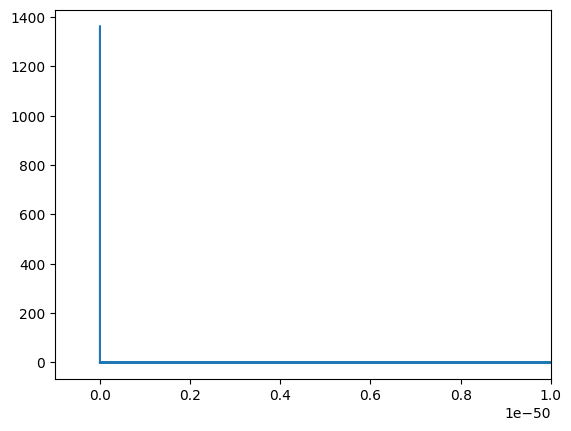

[7.96597806e-18 2.38733132e-17 4.95772011e-17 ... 2.24332690e-03
 2.58425098e-03 2.63811710e-03] [0. 0. 0. ... 0. 0. 0.]


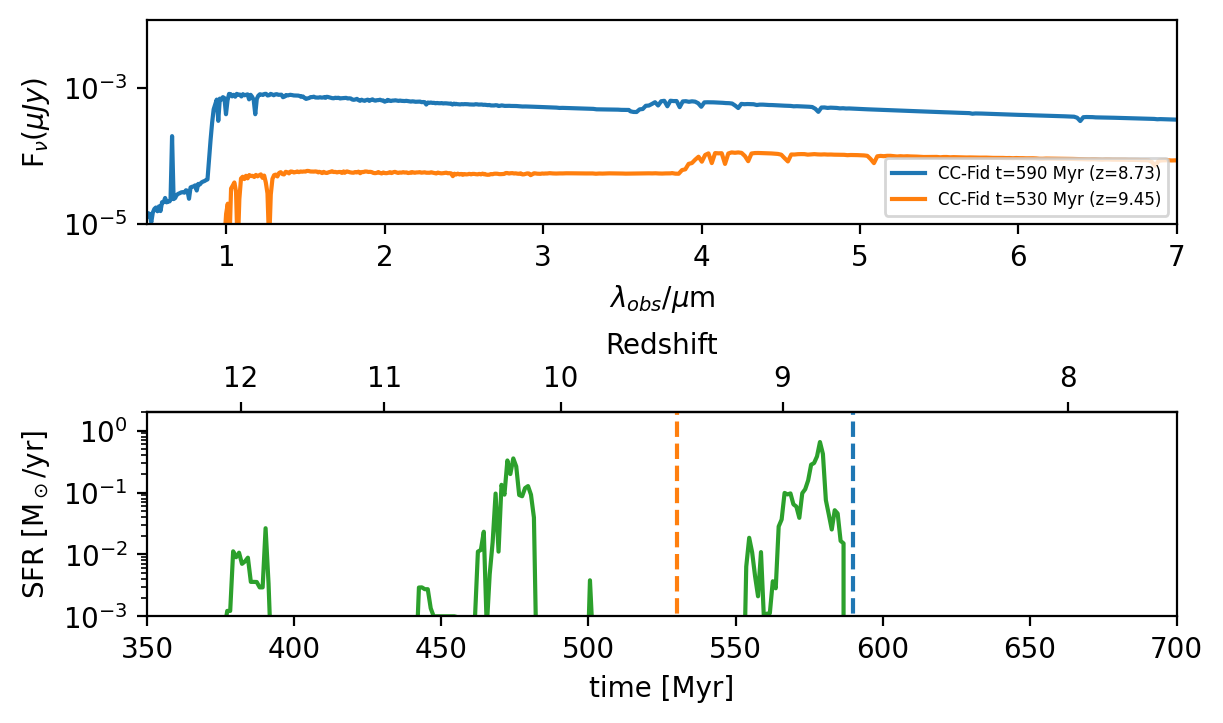

In [13]:
from sed_continuum import sed_cont
wav_obs0, wav_obs1, a1, b1, y_tot0, y_tot1, run, time0, time1, redsh0, redsh1, ti, sfri, Hredshift, Htime, zs, masses = sed_cont()
wav_obs0u = np.array(wav_obs0[a1:b1]) * u.micron
wav_obs1u = np.array(wav_obs1[a1:b1]) * u.micron
out0 = gaussian_spectrum_from_integrated_flux_erg(wav_obs0u.to(u.Angstrom).value, wavelengths, 100, Flumd)
out1 = gaussian_spectrum_from_integrated_flux_erg(wav_obs1u.to(u.Angstrom).value, wavelengths, 100, Flumd)

print(np.max(out0))
plt.plot(out0[10:], wav_obs0[a1+10:b1])
plt.xlim(-1e-51,1e-50)
plt.show()
#gaussian_spectrum_from_integrated_flux_erg(wav_obs0, )
print(y_tot0, out0)
fig, axs = plt.subplots(2,1, figsize = (6,3.5), dpi = 200, constrained_layout = True)
axs[0].plot(wav_obs0[a1:b1], y_tot0+out0*20**3, label=f'{run:s} t={time0:3.0f} Myr (z={redsh0:2.2f})')
axs[0].plot(wav_obs1[a1:b1], y_tot1+out1*20**3, label=f'{run:s} t={time1:3.0f} Myr (z={redsh1:2.2f})')
axs[0].set_yscale('log')
#axs[0].set_yscale('linear')
axs[0].set_xlim(0.5, 7)
#axs[0].set_ylim(1e-25,1e-20)
axs[0].set_ylim(1e-5,1e-2)
axs[0].set_xlabel(r"$\lambda_{obs}/\mu$m")
#axs[0].set_ylabel(r"F$_\lambda(erg/s/cm^2/A)$")
axs[0].set_ylabel(r"F$_\nu(\mu Jy)$")
axs[0].legend(fontsize="6", loc ="lower right")
axs[1].plot([time0,time0],[0,10],'--')
axs[1].plot([time1,time1],[0,10],'--')

#axs[1].plot(ti[1:],sfri1)
#axs[1].plot(ti[1:],sfri2)
#axs[1].plot(ti[1:],sfri3)
axs[1].plot(ti[1:],sfri)

axs[1].set_xlabel(r"time [Myr]")
axs[1].set_ylabel(r"SFR [M$_\odot$/yr]")

secax = axs[1].secondary_xaxis('top', functions=(Hredshift,Htime))
secax.set_xlabel('Redshift')

#fig1= plt.subplots(1, 1)
#ax1.plot(age[1:]-age[:-1])
#print(age[0],age[1],age[2])
#plt.ylim(0.01,4)
axs[1].set_xlim(350,700)
axs[1].set_ylim(1e-3,2.0)

plt.yscale('log')

In [14]:
def save_ax0_data(filename, x, y, redshift=None, description=None):
    """
    Save plotted data from ax[0] to a text file.
    """

    header = "# "
    
    if redshift is not None:
        header += f"Redshift z = {redshift}. "
        
    if description is not None:
        header += description

    header += "\n# columns: x y"

    data = np.column_stack((x, y))

    np.savetxt(
        filename,
        data,
        header=header,
        comments=""
    )


# Example usage
save_ax0_data(
    "output_z3.txt",
    wav_obs0[a1:b1],
    y_tot0+out0*20**3,
    redshift=3, # need to edit this
    description="Mass function extracted from ax[0]"
)

Found directory: /Users/lamoreau/python/ASpec/JWST_FITS_Calibration/NIRSpecdis
Found 7 files:


Found directory: /Users/lamoreau/python/ASpec/JWST_FITS_Calibration/NIRSpecdis
Found 7 files:
Found directory: /Users/lamoreau/python/ASpec/JWST_FITS_Calibration/NIRSpecfil
Found 7 files:
0.08851516270917964 0.019796239212155342 0.019453881914105686


Simulated 21545 NIRSpec pixels from 0.09 micron to 700.19 micron μm
0.08851516270917964 0.007453945581801236 0.019453881914105686
Simulated 2161719 NIRSpec pixels from 0.09 micron to 1361.77 micron μm


(0.0, 7.0)

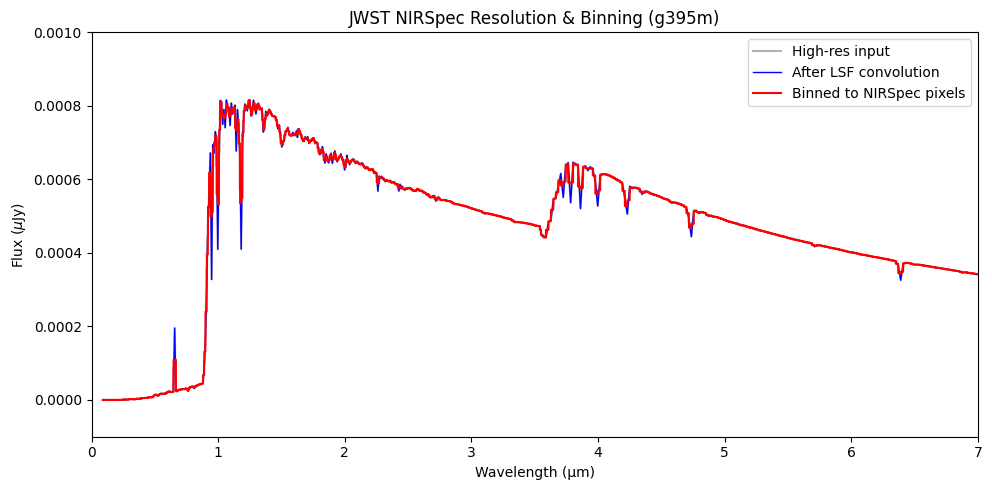

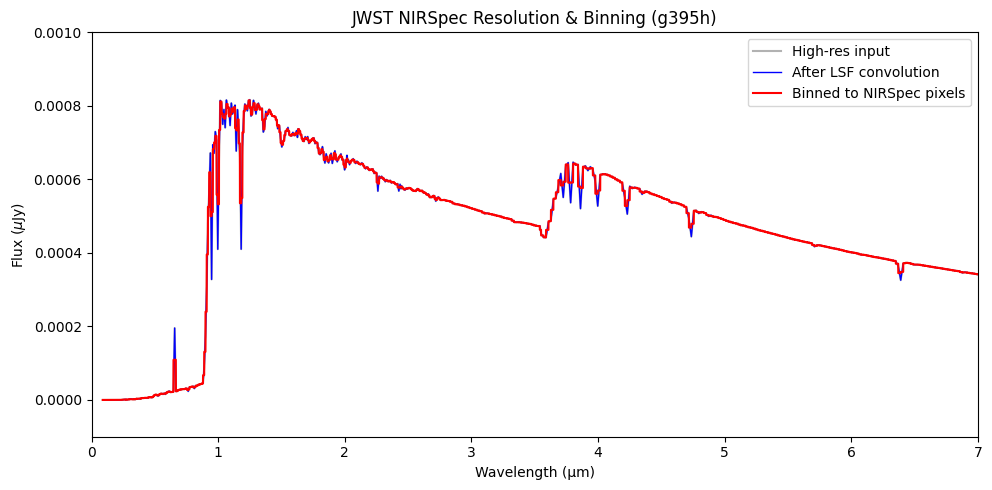

In [15]:
from Fitser_v2 import JWST_disperser, searcher

g395m = JWST_disperser("g395m")
g395h = JWST_disperser("g395h")

g395m.binner(flux_in = y_tot0+out0*20**3, wave_in = wav_obs0[a1:b1])
plt.ylim(-0.0001,0.001)
plt.xlim(0,7)

g395h.binner(flux_in = y_tot0+out0*20**3, wave_in = wav_obs0[a1:b1])
plt.ylim(-0.0001,0.001)
plt.xlim(0,7)

0.08851516270917964 0.007453945581801236 0.019453881914105686
Simulated 2161719 NIRSpec pixels from 0.09 micron to 1361.77 micron μm


(0.0, 7.0)

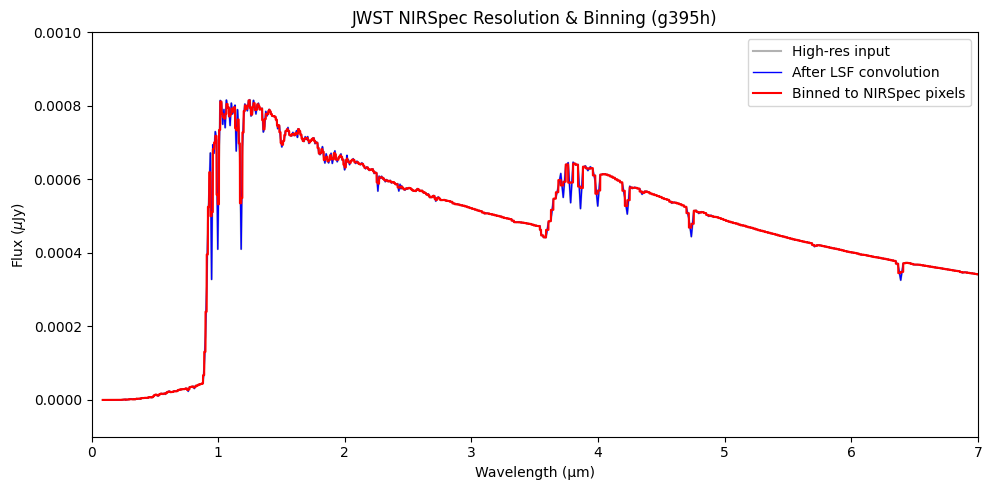

In [16]:
g395h.binner(flux_in = y_tot0+out0, wave_in = wav_obs0[a1:b1])
plt.ylim(-0.0001,0.001)
plt.xlim(0,7)

0.08851516270917964 0.0917816162109375 0.019453881914105686
Simulated 4657 NIRSpec pixels from 0.09 micron to 700.19 micron μm


(0.0, 7.0)

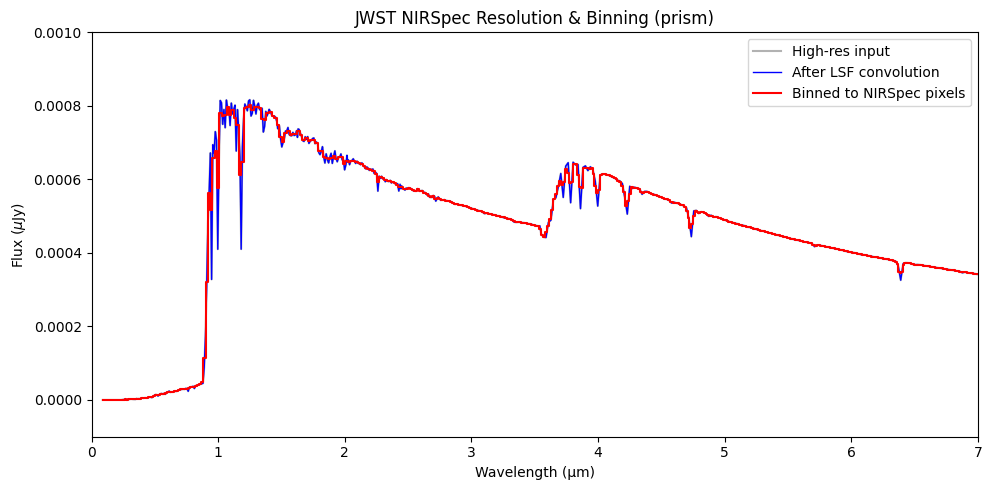

In [17]:
prism = JWST_disperser("prism")

prism.binner(flux_in = y_tot0+out0, wave_in = wav_obs0[a1:b1])
plt.ylim(-0.0001,0.001)
plt.xlim(0,7)

Things to do:
 * NEED AN ARRAY OUTPUT FROM THE ADDING SPECS SO I DON'T HAVE TO KEEP RERUNING!!!
 * Fitser this bitch
   * validate that with some paper that specifically shows resolution
 * Check with lensing that this is the same line emission that they are getting
 * Check out what Pat is up to and get that added if it is fast. If it ain't I think we wait
 * Add in observation modes (how to structure that as a dictionary is interesting, control flow here is probably necessary but how do I make it fast for me)


In [18]:
# flux_fields = [("gas", f"flux_{line}") for line in lines] 
# # Load all fields at once (yt handles this efficiently)
# flux_data = np.vstack([ad_box[f] for f in flux_fields])  # shape: (Nlines, Ncells) #.to("erg/s/cm**2").d
# # Vectorized integration
# total_fluxes_box        = (flux_data * cell_vol).sum(axis=1).to_value()
